##### Testing 02/20/26

Goal: Find optimal performing combination of spatial subsampling, dimensionality reduction, and filtering.

Testing:
- PCA k=20 (elbow) vs PCA k=50 (95% variance) vs no reduction
- 2x2 average pooling vs bilinear downsampling vs no spatial subampling
- Gaussian (low pass) vs Sobel (high pass) vs no filtering

Correct order for applying operations:
> Filtering -> subsampling -> PCA

Why?:
- Subspampling without filtering can cause aliasing
- PCA operates in a different space entirely

In [2]:
# building the layers
import numpy as np
from sklearn.base import TransformerMixin, BaseEstimator

from skimage.filters import gaussian # low pass -> preserve low frequencies (blur)
from skimage.filters import sobel # high pass -> preserve high frequencies (sharpen)
from skimage.transform import downscale_local_mean # 2x2 pooling (average by mean)
from skimage.transform import resize # bilinear sampling by default

# skimage functions aren't actually usable with sklearn Pipeline by default, so i'm going to wrap them in classes so we can use with the Pipeline for everyone's sake

class GaussianFilter(BaseEstimator, TransformerMixin):
    def __init__(self, sigma=1.0, preserve_range=False):
        self.sigma = sigma
        self.preserve_range = preserve_range
    
    def fit(self, X, y=None):
        # nothing to fit
        return self
        
    def transform(self, X):
        # need to apply gaussian filter to all images in dataset
        X_filtered = np.array([
            gaussian(x, sigma=self.sigma, preserve_range=self.preserve_range) for x in X
        ])
        return X_filtered
    
# same for rest
class SobelFilter(BaseEstimator, TransformerMixin):
    def __init__(self, axis=None):
        self.axis = axis

    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X_filtered = np.array([
            sobel(x, axis=self.axis) for x in X
        ])
        return X_filtered
    
class AveragePool(BaseEstimator, TransformerMixin):
    def __init__(self, factor=2):
        self.factor = factor

    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X_pooled = np.array([
            downscale_local_mean(x, factors=(self.factor, self.factor)) for x in X
        ])
        return X_pooled
    
class BilinearResize(BaseEstimator, TransformerMixin):
    def __init__(self, output_shape, preserve_range=False):
        self.output_shape = output_shape
        self.preserve_range = preserve_range

    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X_resized = np.array([
            resize(x, self.output_shape, preserve_range=self.preserve_range) for x in X
        ])
        return X_resized
    

class FlattenTransform(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X_flat = X.reshape(X.shape[0], -1)
        return X_flat

In [3]:
# import dataset

import numpy as np
import random
import matplotlib.pyplot as plt

# looking at file structure
data = np.load("octmnist.npz")

X = data["train_images"]
y = data["train_labels"]
y = y.ravel()
X_val = data["val_images"]
y_val = data["val_labels"]
y_val = y_val.ravel()



rand_sample = random.randint(0, 97476) #74065 good example


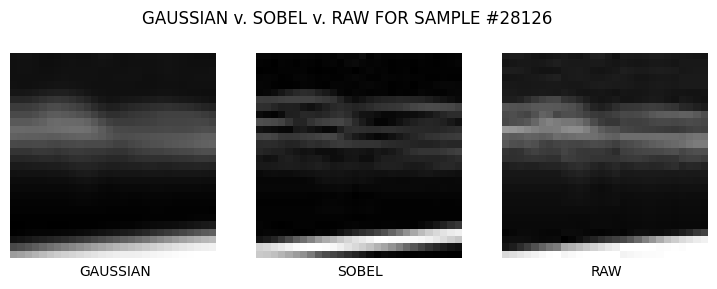

In [4]:
# test filters

filter1 = GaussianFilter(preserve_range=True)
filter2 = SobelFilter()

imgs1 = filter1.transform(X)
imgs2 = filter2.transform(X)

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(9, 3))
axes[0].imshow(imgs1[rand_sample], cmap="gray")
axes[0].text(9, 30, "GAUSSIAN")
axes[1].imshow(imgs2[rand_sample], cmap="gray")
axes[1].text(10.5, 30, "SOBEL")
axes[2].imshow(X[rand_sample], cmap="gray")
axes[2].text(11.5, 30, "RAW")
for ax in axes:
    ax.axis("off")
fig.suptitle("GAUSSIAN v. SOBEL v. RAW FOR SAMPLE #{}".format(rand_sample))

plt.show()

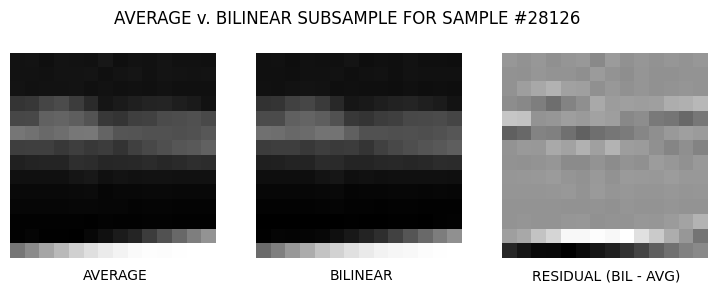

In [5]:
# test downsampling

size1 = AveragePool()
size2 = BilinearResize(output_shape=(14, 14), preserve_range=True)

imgs3 = size1.transform(X)
imgs4 = size2.transform(X)

diff = imgs4[rand_sample] - imgs3[rand_sample] # subtracting to show that subsampling choice isn't redundant

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(9, 3))
axes[0].imshow(imgs3[rand_sample], cmap="gray")
axes[0].text(4.5, 15, "AVERAGE")
axes[1].imshow(imgs4[rand_sample], cmap="gray")
axes[1].text(4.5, 15, "BILINEAR")
axes[2].imshow(diff, cmap="gray") # structure is left over -> if they were redundant, their subtraction would be one flat color
axes[2].text(1.5, 15, "RESIDUAL (BIL - AVG)")
for ax in axes:
    ax.axis("off")
fig.suptitle("AVERAGE v. BILINEAR SUBSAMPLE FOR SAMPLE #{}".format(rand_sample))

plt.show()

In [6]:
# create and execute pipeline

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

from sklearn.pipeline import Pipeline
from itertools import product

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# the idea is to do a manual grid search, because i personally hate black boxes and want to see all the numbers myself. grid search would also work, though

filters = [None, GaussianFilter(sigma=1.0, preserve_range=True), SobelFilter()]
subsamples = [None, AveragePool(factor=2), BilinearResize(output_shape=(14, 14), preserve_range=True)]
pca_values = [None, 50] # k=20 decimates results, want to speed up computation

results = {}

for f, s, k in product(filters, subsamples, pca_values):
    steps=[]

    if f is not None:
        steps.append(("filter", f))
    if s is not None:
        steps.append(("subsample", s))

    # prediction (and pca) requires different space, img input is n x 28 x 28 -> need n x 784
    steps.append(("flatten", FlattenTransform()))
    steps.append(("scaler", StandardScaler()))

    if k is not None: 
        steps.append(("pca", PCA(n_components=k)))

    # regardless, we will evaluate with basic logistic regression
    steps.append(("clf", LogisticRegression(max_iter=2000, C=0.5, class_weight="balanced"))) # NOTE: class 2 was being completely collapsed (0 recall across the board) before balanced weights

    # and actually run
    model = Pipeline(steps)
    model.fit(X, y) # X and y are the train set only

    # use validation set to score
    score = model.score(X_val, y_val) #interim
    y_pred = model.predict(X_val) 

    model_desc = " -> ".join(step.__class__.__name__ for step in model.named_steps.values())
    report = classification_report(y_val, y_pred)
    results[model_desc] = report

    print("{} => SCORE: {}".format(model_desc, score))
    

FlattenTransform -> StandardScaler -> LogisticRegression => SCORE: 0.5645310192023634
FlattenTransform -> StandardScaler -> PCA -> LogisticRegression => SCORE: 0.47959748892171344
AveragePool -> FlattenTransform -> StandardScaler -> LogisticRegression => SCORE: 0.5543759231905465
AveragePool -> FlattenTransform -> StandardScaler -> PCA -> LogisticRegression => SCORE: 0.5001846381093058
BilinearResize -> FlattenTransform -> StandardScaler -> LogisticRegression => SCORE: 0.555576070901034
BilinearResize -> FlattenTransform -> StandardScaler -> PCA -> LogisticRegression => SCORE: 0.507754800590842


/home/brew/Repositories/BME_Final_Project/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


GaussianFilter -> FlattenTransform -> StandardScaler -> LogisticRegression => SCORE: 0.5664697193500738
GaussianFilter -> FlattenTransform -> StandardScaler -> PCA -> LogisticRegression => SCORE: 0.5244645494830132
GaussianFilter -> AveragePool -> FlattenTransform -> StandardScaler -> LogisticRegression => SCORE: 0.5588995568685377
GaussianFilter -> AveragePool -> FlattenTransform -> StandardScaler -> PCA -> LogisticRegression => SCORE: 0.5261262924667651
GaussianFilter -> BilinearResize -> FlattenTransform -> StandardScaler -> LogisticRegression => SCORE: 0.5590841949778435
GaussianFilter -> BilinearResize -> FlattenTransform -> StandardScaler -> PCA -> LogisticRegression => SCORE: 0.5280649926144756
SobelFilter -> FlattenTransform -> StandardScaler -> LogisticRegression => SCORE: 0.5761632200886263
SobelFilter -> FlattenTransform -> StandardScaler -> PCA -> LogisticRegression => SCORE: 0.42042097488921715
SobelFilter -> AveragePool -> FlattenTransform -> StandardScaler -> LogisticReg

In [7]:
for model, report in results.items():
    print("MODEL:", model)
    print("\n", report,"\n")

MODEL: FlattenTransform -> StandardScaler -> LogisticRegression

               precision    recall  f1-score   support

           0       0.70      0.57      0.63      3721
           1       0.38      0.53      0.44      1135
           2       0.14      0.37      0.21       862
           3       0.76      0.61      0.67      5114

    accuracy                           0.56     10832
   macro avg       0.50      0.52      0.49     10832
weighted avg       0.65      0.56      0.60     10832
 

MODEL: FlattenTransform -> StandardScaler -> PCA -> LogisticRegression

               precision    recall  f1-score   support

           0       0.63      0.48      0.55      3721
           1       0.14      0.25      0.18      1135
           2       0.12      0.24      0.16       862
           3       0.68      0.57      0.62      5114

    accuracy                           0.48     10832
   macro avg       0.39      0.38      0.38     10832
weighted avg       0.56      0.48      0.51 

Notes:
- PCA even beyond the elbow at k=50 (~95% variance) seems to decimate the features required to differentiate classes 1 and 2, which would make sense if the discriminatory features for those classes live in the detailed morphological structure
- Sobel with no subsampling giving us the highest macro f1 overall and highest recall for class 2, which supports the idea that higher frequency features and boundaries may be more important for linear discrimination
- Logistic regression is likely not an ideal model for this biological data considering overall performance, strong likelihood of nonlinear class boundaries, especially evident "battleground" classes, 1 (~10%) and 2 (~8%).

Next step: try a Random Forest classifier.

In [8]:
# random forest pipeline

from sklearn.ensemble import RandomForestClassifier

results_tree = {}
results_confusion = {}

for f, s in product(filters, subsamples):
    steps=[]

    if f is not None:
        steps.append(("filter", f))
    if s is not None:
        steps.append(("subsample", s))

    # prediction (and pca) requires different space, img input is n x 28 x 28 -> need n x 784
    steps.append(("flatten", FlattenTransform()))

    # no pca or scaling for now (trees don't need scaling, pca harms)

    # now try a random forest classifier instead
    steps.append(("rf", RandomForestClassifier(n_estimators=300, class_weight="balanced", max_features="sqrt", n_jobs=-1, random_state=42)))

    model = Pipeline(steps)
    model.fit(X, y) # X and y are the train set only

    score = model.score(X_val, y_val)
    y_pred = model.predict(X_val) 

    model_desc = " -> ".join(step.__class__.__name__ for step in model.named_steps.values())
    report = classification_report(y_val, y_pred)
    confuse = confusion_matrix(y_val, y_pred)
    
    results_tree[model_desc] = report
    results_confusion[model_desc] = confuse

    print("{} => SCORE: {}".format(model_desc, score))

FlattenTransform -> RandomForestClassifier => SCORE: 0.8080686853766618
AveragePool -> FlattenTransform -> RandomForestClassifier => SCORE: 0.7906203840472673
BilinearResize -> FlattenTransform -> RandomForestClassifier => SCORE: 0.7885893648449039
GaussianFilter -> FlattenTransform -> RandomForestClassifier => SCORE: 0.7926514032496307
GaussianFilter -> AveragePool -> FlattenTransform -> RandomForestClassifier => SCORE: 0.7852658788774003
GaussianFilter -> BilinearResize -> FlattenTransform -> RandomForestClassifier => SCORE: 0.7812961595273265
SobelFilter -> FlattenTransform -> RandomForestClassifier => SCORE: 0.7807422451994092
SobelFilter -> AveragePool -> FlattenTransform -> RandomForestClassifier => SCORE: 0.7738183161004432
SobelFilter -> BilinearResize -> FlattenTransform -> RandomForestClassifier => SCORE: 0.7768648449039882


In [ ]:
for model, report in results_tree.items():
    print("MODEL:", model)
    print("\n", report,"\n")

MODEL: FlattenTransform -> RandomForestClassifier

               precision    recall  f1-score   support

           0       0.85      0.85      0.85      3721
           1       0.95      0.48      0.64      1135
           2       0.84      0.15      0.26       862
           3       0.77      0.96      0.85      5114

    accuracy                           0.81     10832
   macro avg       0.85      0.61      0.65     10832
weighted avg       0.82      0.81      0.78     10832
 

MODEL: AveragePool -> FlattenTransform -> RandomForestClassifier

               precision    recall  f1-score   support

           0       0.82      0.83      0.82      3721
           1       0.95      0.45      0.61      1135
           2       0.84      0.15      0.26       862
           3       0.76      0.95      0.84      5114

    accuracy                           0.79     10832
   macro avg       0.84      0.59      0.63     10832
weighted avg       0.81      0.79      0.77     10832
 

MODEL: 

In [ ]:
for model, report in results_confusion.items(): #row = true class, col = predicted class, 0-3
    print("MODEL:", model)
    print("\n", report,"\n")

MODEL: FlattenTransform -> RandomForestClassifier

 [[3171   19   19  512]
 [ 222  548    0  365]
 [ 147    4  130  581]
 [ 196    8    6 4904]] 

MODEL: AveragePool -> FlattenTransform -> RandomForestClassifier

 [[3091   19   20  591]
 [ 249  506    0  380]
 [ 171    5  131  555]
 [ 269    4    5 4836]] 

MODEL: BilinearResize -> FlattenTransform -> RandomForestClassifier

 [[3067   33   19  602]
 [ 251  494    0  390]
 [ 170    4  131  557]
 [ 254    5    5 4850]] 

MODEL: GaussianFilter -> FlattenTransform -> RandomForestClassifier

 [[3058   39   21  603]
 [ 230  541    0  364]
 [ 157    7  142  556]
 [ 252   12    5 4845]] 

MODEL: GaussianFilter -> AveragePool -> FlattenTransform -> RandomForestClassifier

 [[3044   34   21  622]
 [ 256  491    0  388]
 [ 169    4  144  545]
 [ 273    8    6 4827]] 

MODEL: GaussianFilter -> BilinearResize -> FlattenTransform -> RandomForestClassifier

 [[3035   37   20  629]
 [ 261  476    0  398]
 [ 163    4  139  556]
 [ 282   13    6 4813]] 

Notes:
- Very large jump in accuracy tells us this data requires nonlinear decision capability for accurate discrimination
- Across the board, recall is very low for class 2. When the model predicts class 2, it's often right (precision ~0.95), but it almost never predicts class 2 (recall ~0.15). This is not just a linear separabliity issue, and more so points to a representation quality issue (possible overlap between classes 2 and 3 in feature space)
- Confusion matrix confirms that class 2 is being systematically absorbed into class 3, as the distribution pattern is clear over all features tested
- Sobel no longer helps, and Gaussian filtering instead provides a bit of a boost for the trees. This suggests that different models utilize features differently, and further supports the idea that there may be an overall representation issue.

> However, there is no such thing as one "ideal" representation for any model. These are not independent, and while model capacity can be greatly influenced by representation quality, representation utilization maximization ultimately depends on the capability of the model.

We shall try one more test (feature aggregation) to see if redundancy improves tree discrimination: concatenating raw + Sobel features.

In [ ]:
# testing 1 pipeline with 2 feature matrices

gaus_raw = Pipeline(steps=[
    ("gaus", GaussianFilter(sigma=1.0, preserve_range=True)),
    ("flatten", FlattenTransform()),
    ("rf", RandomForestClassifier(n_estimators=300, class_weight="balanced", max_features="sqrt", n_jobs=-1, random_state=42))
])

# aggregate features on train and validation sets
X_sobel = np.array([sobel(x) for x in X])
X_agg = np.hstack([X, X_sobel])

X_val_sobel = np.array([sobel(x) for x in X_val])
X_val_agg = np.hstack([X_val, X_val_sobel])

# train and validate
gaus_raw.fit(X_agg, y)
y_pred_agg = gaus_raw.predict(X_val_agg)

print("CONFUSION MATRIX:")
print(confusion_matrix(y_val, y_pred_agg))
print("\nREPORT:")
print(classification_report(y_val, y_pred_agg))

CONFUSION MATRIX:
[[3296   17   22  386]
 [ 254  535    0  346]
 [ 185    6  148  523]
 [ 210    7   10 4887]]

REPORT:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      3721
           1       0.95      0.47      0.63      1135
           2       0.82      0.17      0.28       862
           3       0.80      0.96      0.87      5114

    accuracy                           0.82     10832
   macro avg       0.85      0.62      0.66     10832
weighted avg       0.83      0.82      0.79     10832



In [104]:
# old model results for reference:

print("CONFUSION MATRIX (NO AGG):")
print(results_confusion["GaussianFilter -> FlattenTransform -> RandomForestClassifier"])
print("\nREPORT (NO AGG):")
print(results_tree["GaussianFilter -> FlattenTransform -> RandomForestClassifier"])

CONFUSION MATRIX (NO AGG):
[[3058   39   21  603]
 [ 230  541    0  364]
 [ 157    7  142  556]
 [ 252   12    5 4845]]

REPORT (NO AGG):
              precision    recall  f1-score   support

           0       0.83      0.82      0.82      3721
           1       0.90      0.48      0.62      1135
           2       0.85      0.16      0.28       862
           3       0.76      0.95      0.84      5114

    accuracy                           0.79     10832
   macro avg       0.83      0.60      0.64     10832
weighted avg       0.81      0.79      0.77     10832



Notes:
- Overall macro improved, but not by much (0.64 -> 0.66), and class 2 recall stayed basically the same (0.16 -> 0.17)
- The model clearly benefits overall from increased edge information, which supports earlier speculation, but this also highlights that we may be facing an overlap between classes 2 and 3 that shallow representation cannot fully separate

Conclusion:
> This investigation overall indicates that we may be hitting the ceiling of what handcrafted features can do for this dataset. The optimal classical representation for tree-based models, of the features tested, is raw pixel intensities optionally augmented with edge information, but such features fail to substantially improve seperability of class 2. This suggests intrinstic overlap in handcrafted feature space.

The next logical step up for enhanced representation is deep learning.